<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_2_Convolution_and_LTI_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Linear Time-Invariant system properties, impulse response, and discrete convolution equations.

The Project: Create a custom audio reverb engine from scratch by convolving a dry vocal track with an impulse response file.

In [ ]:
import numpy as np
import scipy.signal as signal
import soundfile as sf

def apply_convolution_reverb(dry_path, ir_path, output_path, wet_gain=0.4, dry_gain=0.8):
    """
    Convolves a dry audio file with an impulse response file to create a custom reverb.

    Parameters:
        - dry_path: Path to the clean vocal/instrument wav file.
        - ir_path: Path to the acoustic space impulse response wav file.
        - output_path: Path where the processed audio will be saved.
        - wet_gain: Volume factor of the reverberated signal (0.0 to 1.0).
        - dry_gain: Volume factor of the original clean signal (0.0 to 1.0).
    """
    # 1. Load the audio files
    dry_data, dry_sr = sf.read(dry_path)
    ir_data, ir_sr = sf.read(ir_path)

    # 2. Hardware Safety Guardrail: Match Sample Rates
    if dry_sr != ir_sr:
        raise ValueError(f"Sample rates do not match! Dry: {dry_sr}Hz, IR: {ir_sr}Hz. "
                         f"Resample one of the files before convolving.")

    # 3. Handle Channel Configurations (Mono vs Stereo)
    # If IR is stereo and dry is mono, duplicate mono dry to stereo
    if len(ir_data.shape) > 1 and len(dry_data.shape) == 1:
        dry_data = np.stack((dry_data, dry_data), axis=-1)
    # If dry is stereo and IR is mono, duplicate mono IR to stereo
    elif len(dry_data.shape) > 1 and len(ir_data.shape) == 1:
        ir_data = np.stack((ir_data, ir_data), axis=-1)

    print("Convolving signals in the frequency domain...")

    # 4. Perform Frequency-Domain Convolution
    if len(dry_data.shape) == 1:
        # Mono Processing
        wet_signal = signal.fftconvolve(dry_data, ir_data, mode='full')
    else:
        # Stereo Processing (Convolve each channel independently)
        left_channel = signal.fftconvolve(dry_data[:, 0], ir_data[:, 0], mode='full')
        right_channel = signal.fftconvolve(dry_data[:, 1], ir_data[:, 1], mode='full')
        wet_signal = np.stack((left_channel, right_channel), axis=-1)

    # 5. Align Timelines (Zero-padding the dry signal to match the extended wet signal)
    # Convolution extends the length of the file to: len(dry) + len(ir) - 1
    pad_amount = wet_signal.shape[0] - dry_data.shape[0]
    if len(dry_data.shape) == 1:
        dry_padded = np.pad(dry_data, (0, pad_amount), 'constant')
    else:
        dry_padded = np.pad(dry_data, ((0, pad_amount), (0, 0)), 'constant')

    # 6. Linear Mixing (Dry + Wet)
    mixed_output = (dry_gain * dry_padded) + (wet_gain * wet_signal)

    # 7. Normalization Guardrail (Prevents digital clipping/distortion)
    max_val = np.max(np.abs(mixed_output))
    if max_val > 1.0:
        mixed_output = mixed_output / max_val
        print("Signal normalized to prevent digital clipping.")

    # 8. Export the Output
    sf.write(output_path, mixed_output, dry_sr)
    print(f"Successfully rendered: {output_path}")

# Example usage (Replace with actual paths to your WAV files)
# apply_convolution_reverb("dry_vocals.wav", "cathedral_ir.wav", "reverb_vocals.wav", wet_gain=0.3, dry_gain=0.9)

Visualization

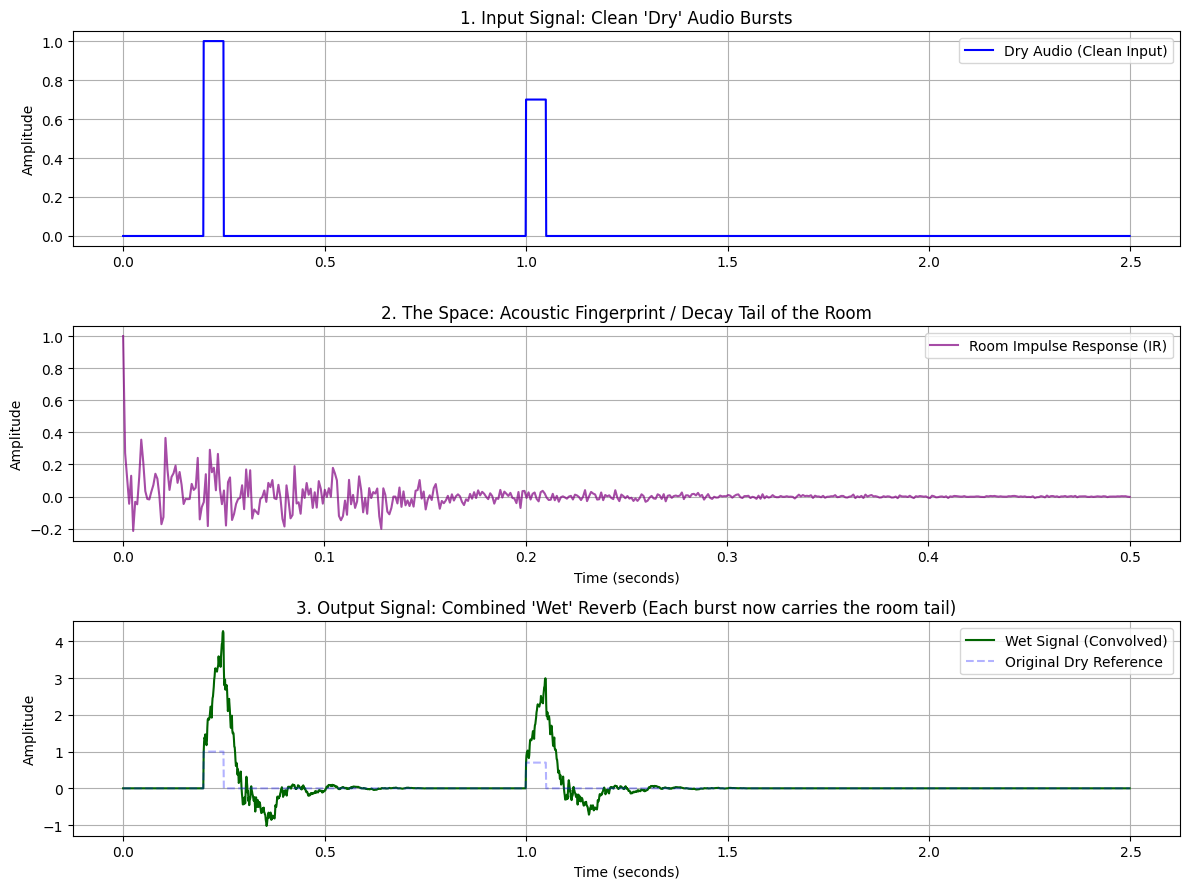

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def visualize_reverb_engine():
    # 1. Generate Mock Signals
    fs = 1000  # Sampling frequency for visualization
    t = np.linspace(0, 2, 2000, endpoint=False)

    # Create Dry Audio: Two clean, distinct audio bursts (impulses)
    dry_audio = np.zeros_like(t)
    dry_audio[200:250] = 1.0   # First spoken word / sound burst
    dry_audio[1000:1050] = 0.7 # Second spoken word / sound burst

    # Create Impulse Response (IR): Exponentially decaying white noise (a room tail)
    ir_t = np.linspace(0, 0.5, 500, endpoint=False)
    noise = np.random.normal(0, 0.2, len(ir_t))
    decay = np.exp(-10 * ir_t)
    impulse_response = noise * decay
    # Ensure it starts with a strong initial reflection
    impulse_response[0] = 1.0

    # 2. Process via Frequency Domain Convolution (The Engine)
    # This matches the exact math: IFFT( FFT(x) * FFT(h) )
    wet_signal = signal.fftconvolve(dry_audio, impulse_response, mode='full')
    t_wet = np.linspace(0, len(wet_signal)/fs, len(wet_signal), endpoint=False)

    # Pad dry audio with zeros to match the timeline layout of the wet signal
    dry_padded = np.pad(dry_audio, (0, len(wet_signal) - len(dry_audio)), 'constant')

    # 3. Plotting the Transformation
    plt.figure(figsize=(12, 9))

    # Plot 1: The Input (Dry Audio)
    plt.subplot(3, 1, 1)
    plt.plot(t_wet, dry_padded, color='blue', linewidth=1.5, label="Dry Audio (Clean Input)")
    plt.title("1. Input Signal: Clean 'Dry' Audio Bursts")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend(loc="upper right")

    # Plot 2: The Acoustic Space (Impulse Response)
    plt.subplot(3, 1, 2)
    # We plot this on its own smaller timeline to see the decay profile
    t_ir = np.linspace(0, len(impulse_response)/fs, len(impulse_response))
    plt.plot(t_ir, impulse_response, color='purple', alpha=0.7, label="Room Impulse Response (IR)")
    plt.title("2. The Space: Acoustic Fingerprint / Decay Tail of the Room")
    plt.ylabel("Amplitude")
    plt.xlabel("Time (seconds)")
    plt.grid(True)
    plt.legend(loc="upper right")

    # Plot 3: The Output (Wet Reverberated Audio)
    plt.subplot(3, 1, 3)
    plt.plot(t_wet, wet_signal, color='darkgreen', linewidth=1.5, label="Wet Signal (Convolved)")
    plt.plot(t_wet, dry_padded, color='blue', alpha=0.3, linestyle='--', label="Original Dry Reference")
    plt.title("3. Output Signal: Combined 'Wet' Reverb (Each burst now carries the room tail)")
    plt.ylabel("Amplitude")
    plt.xlabel("Time (seconds)")
    plt.grid(True)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_reverb_engine()